# Olist SQL Analizi: Görselleştirme ve Veri Hikayesi

Bu notebook'ta bütün filtreleme, gruplama ve metrik hesapları PostgreSQL üzerinde yapılır. Python yalnızca sorgu sonuçlarını görüntülemek ve grafik üretmek için kullanılır.

In [1]:
import os
from pathlib import Path
from urllib.parse import quote_plus

import matplotlib.pyplot as plt
import pandas as pd
from dotenv import load_dotenv
from sqlalchemy import create_engine, text

env_file = next(
    (path / '.env' for path in (Path.cwd(), *Path.cwd().parents) if (path / '.env').exists()),
    None,
)
if env_file is None:
    raise FileNotFoundError('Repo kökünde .env dosyası bulunamadı.')
load_dotenv(env_file)

host = os.getenv('OLIST_DB_HOST', 'localhost')
database = os.getenv('OLIST_DB_NAME', 'olist')
user = os.getenv('OLIST_DB_USER', 'postgres')
password = quote_plus(os.environ['OLIST_DB_PASSWORD'])
engine = create_engine(
    f'postgresql+psycopg2://{user}:{password}@{host}:5432/{database}'
)

plt.style.use('seaborn-v0_8-whitegrid')
COLORS = ['#287271', '#E07A5F', '#3D5A80', '#F2CC8F', '#6D597A']

## 1. Sipariş durumlarının dağılımı

İlk görünüm, siparişlerin operasyonel olarak hangi aşamalarda sonuçlandığını gösterir.

In [2]:
order_status = pd.read_sql_query(text("""
SELECT
    order_status,
    COUNT(*) AS total_orders,
    ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (), 2) AS percentage
FROM orders
GROUP BY order_status
ORDER BY total_orders DESC;
"""), engine)
order_status

,order_status,total_orders,percentage
0,delivered,96478,97.02
1,shipped,1107,1.11
2,canceled,625,0.63
3,unavailable,609,0.61
4,invoiced,314,0.32
5,processing,301,0.30
6,created,5,0.01
7,approved,2,0.00


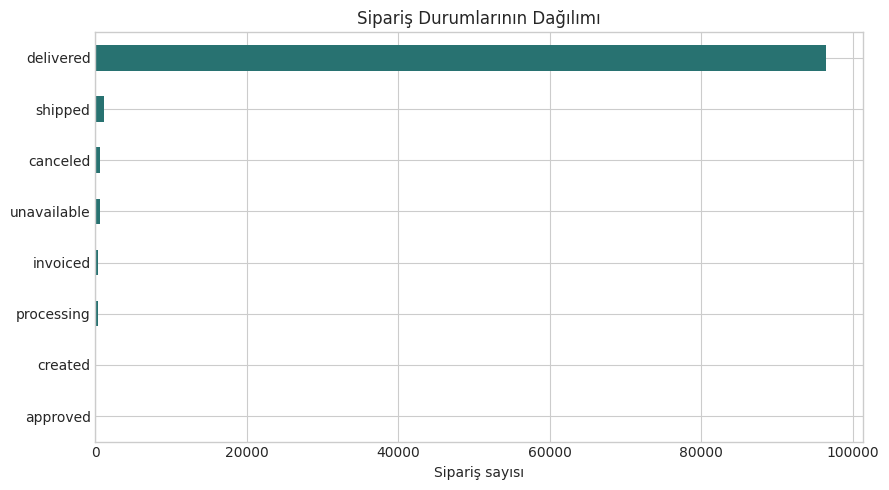

In [3]:
ax = order_status.sort_values('total_orders').plot.barh(
    x='order_status', y='total_orders', legend=False, color=COLORS[0], figsize=(9, 5)
)
ax.set(title='Sipariş Durumlarının Dağılımı', xlabel='Sipariş sayısı', ylabel='')
plt.tight_layout()
plt.show()

**Yorum:** Teslim edilen siparişlerin toplam içindeki payı operasyonun ana başarı göstergesidir. İptal ve teslim edilememe oranları ayrıca izlenmelidir.

## 2. Aylık sipariş ve gelir trendi

Yalnızca teslim edilmiş siparişler kullanılarak hacim ve ödeme geliri birlikte incelenir.

In [4]:
monthly_trend = pd.read_sql_query(text("""
SELECT
    DATE_TRUNC('month', o.order_purchase)::date AS order_month,
    COUNT(DISTINCT o.order_id) AS total_orders,
    ROUND(SUM(op.payment_value)::numeric, 2) AS total_revenue
FROM orders AS o
JOIN order_payments AS op ON o.order_id = op.order_id
WHERE o.order_status = 'delivered'
GROUP BY DATE_TRUNC('month', o.order_purchase)
ORDER BY order_month;
"""), engine)
monthly_trend

,order_month,total_orders,total_revenue
0,2016-10-01,265,46566.71
1,2016-12-01,1,19.62
2,2017-01-01,750,127545.67
3,2017-02-01,1653,271298.65
4,2017-03-01,2546,414369.39
5,2017-04-01,2303,390952.18
6,2017-05-01,3546,567066.73
7,2017-06-01,3135,490225.60
8,2017-07-01,3872,566403.93
9,2017-08-01,4193,646000.61


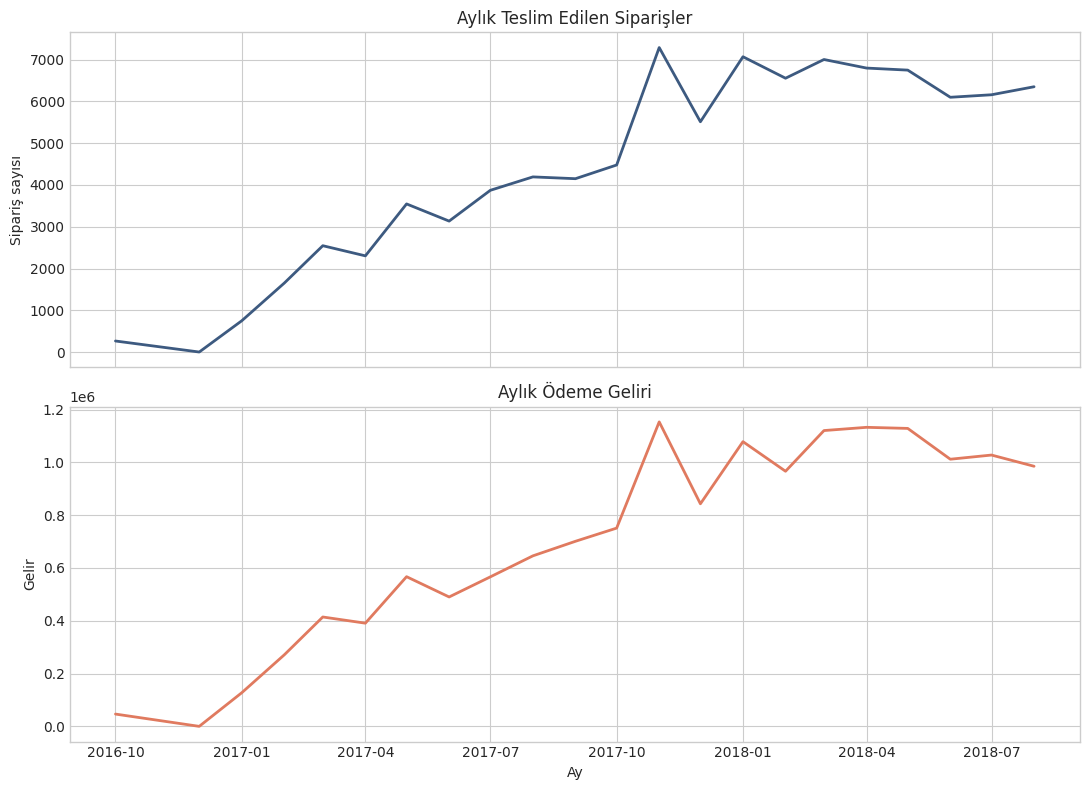

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=True)
axes[0].plot(monthly_trend['order_month'], monthly_trend['total_orders'], color=COLORS[2], linewidth=2)
axes[0].set(title='Aylık Teslim Edilen Siparişler', ylabel='Sipariş sayısı')
axes[1].plot(monthly_trend['order_month'], monthly_trend['total_revenue'], color=COLORS[1], linewidth=2)
axes[1].set(title='Aylık Ödeme Geliri', xlabel='Ay', ylabel='Gelir')
plt.tight_layout()
plt.show()

**Yorum:** Sipariş hacmi ile gelirin aynı yönde hareket edip etmediği, büyümenin adet artışından mı yoksa sipariş değerinden mi geldiğini anlamaya yardımcı olur.

## 3. En yüksek gelirli ürün kategorileri

Ürün fiyatları üzerinden hesaplanan brüt ürün geliri kategori bazında karşılaştırılır.

In [6]:
category_revenue = pd.read_sql_query(text("""
SELECT
    COALESCE(t.category_translation, p.product_category) AS category_name,
    COUNT(*) AS total_items_sold,
    ROUND(SUM(oi.price)::numeric, 2) AS total_revenue
FROM order_items AS oi
JOIN products AS p ON oi.product_id = p.product_id
LEFT JOIN product_translation AS t
    ON p.product_category = t.category
JOIN orders AS o ON oi.order_id = o.order_id
WHERE o.order_status = 'delivered'
GROUP BY COALESCE(t.category_translation, p.product_category)
ORDER BY total_revenue DESC
LIMIT 10;
"""), engine)
category_revenue

,category_name,total_items_sold,total_revenue
0,health_beauty,9465,1233131.72
1,watches_gifts,5859,1166176.98
2,bed_bath_table,10953,1023434.76
3,sports_leisure,8431,954852.55
4,computers_accessories,7644,888724.61
5,furniture_decor,8160,711927.69
6,housewares,6795,615628.69
7,cool_stuff,3718,610204.10
8,auto,4140,578966.65
9,toys,4030,471286.48


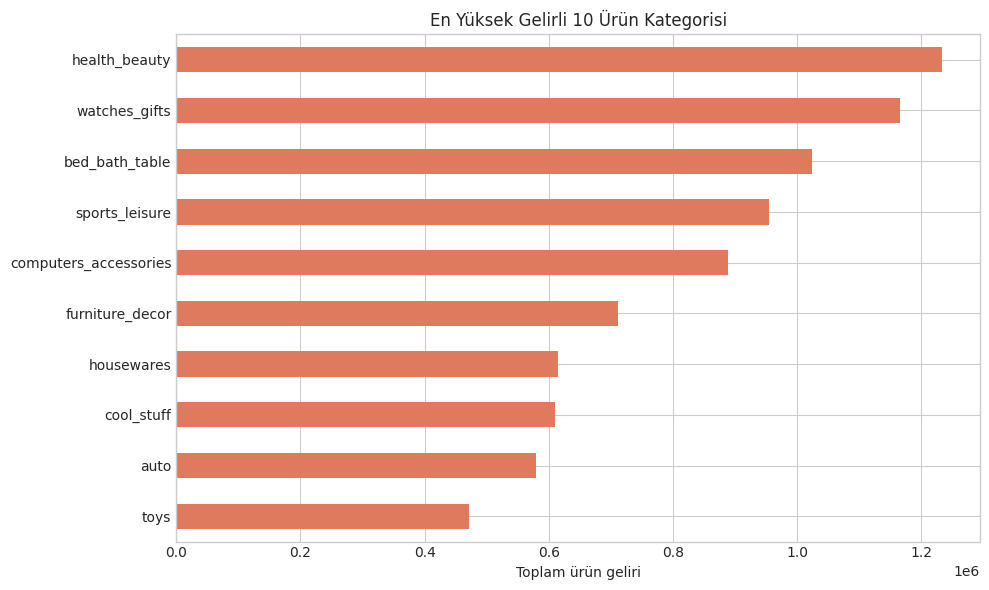

In [7]:
ax = category_revenue.sort_values('total_revenue').plot.barh(
    x='category_name', y='total_revenue', legend=False, color=COLORS[1], figsize=(10, 6)
)
ax.set(title='En Yüksek Gelirli 10 Ürün Kategorisi', xlabel='Toplam ürün geliri', ylabel='')
plt.tight_layout()
plt.show()

**Yorum:** Yüksek gelir üreten kategoriler stok, kampanya ve satıcı geliştirme kararlarında önceliklendirilebilir. Gelir ile satılan ürün adedi birlikte değerlendirilmelidir.

## 4. Eyaletlere göre teslimat süresi

Teslim edilmiş siparişlerde satın alma ile müşteriye teslim arasındaki ortalama süre ölçülür.

In [8]:
delivery_by_state = pd.read_sql_query(text("""
SELECT
    c.customer_state,
    ROUND(AVG(EXTRACT(EPOCH FROM (o.order_delivered_customer - o.order_purchase)) / 86400.0)::numeric, 2) AS avg_delivery_days,
    COUNT(*) AS delivered_orders
FROM orders AS o
JOIN customers AS c ON o.customer_id = c.customer_id
WHERE o.order_status = 'delivered'
  AND o.order_delivered_customer IS NOT NULL
  AND o.order_purchase IS NOT NULL
GROUP BY c.customer_state
ORDER BY avg_delivery_days DESC;
"""), engine)
delivery_by_state

,customer_state,avg_delivery_days,delivered_orders
0,RR,29.39,41
1,AP,27.19,67
2,AM,26.43,145
3,AL,24.54,397
4,PA,23.77,946
5,MA,21.57,717
6,SE,21.52,335
7,CE,21.27,1279
8,AC,21.04,80
9,PB,20.43,517


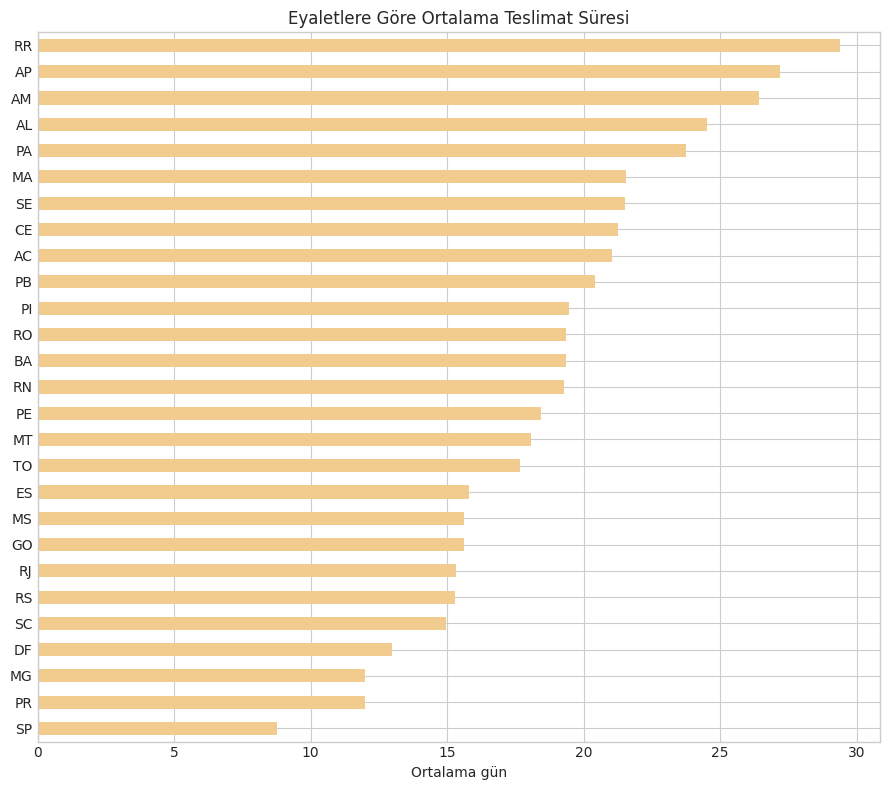

In [9]:
ax = delivery_by_state.sort_values('avg_delivery_days').plot.barh(
    x='customer_state', y='avg_delivery_days', legend=False, color=COLORS[3], figsize=(9, 8)
)
ax.set(title='Eyaletlere Göre Ortalama Teslimat Süresi', xlabel='Ortalama gün', ylabel='')
plt.tight_layout()
plt.show()

**Yorum:** Ortalama teslimat süresi yüksek eyaletler lojistik kapasite, rota ve satıcı konumu açısından incelenmelidir. Düşük sipariş hacimli eyaletlerde ortalamanın daha oynak olabileceği unutulmamalıdır.

## 5. Ödeme yöntemlerinin dağılımı

Ödeme yöntemleri işlem sayısı ve toplam ödeme değeri açısından karşılaştırılır.

In [10]:
payment_types = pd.read_sql_query(text("""
SELECT
    payment_type,
    COUNT(*) AS total_transactions,
    ROUND(SUM(payment_value)::numeric, 2) AS total_payment_value,
    ROUND(AVG(payment_installments)::numeric, 1) AS avg_installments
FROM order_payments
GROUP BY payment_type
ORDER BY total_payment_value DESC;
"""), engine)
payment_types

,payment_type,total_transactions,total_payment_value,avg_installments
0,credit_card,76795,12542084.19,3.5
1,boleto,19784,2869361.27,1.0
2,voucher,5775,379436.87,1.0
3,debit_card,1529,217989.79,1.0
4,not_defined,3,0.00,1.0


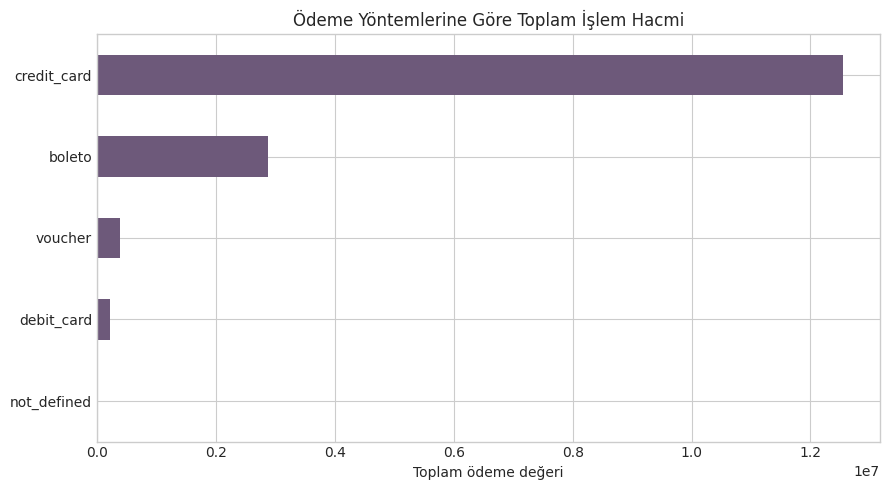

In [11]:
ax = payment_types.sort_values('total_payment_value').plot.barh(
    x='payment_type', y='total_payment_value', legend=False, color=COLORS[4], figsize=(9, 5)
)
ax.set(title='Ödeme Yöntemlerine Göre Toplam İşlem Hacmi', xlabel='Toplam ödeme değeri', ylabel='')
plt.tight_layout()
plt.show()

**Yorum:** En yüksek işlem hacmini oluşturan ödeme yöntemi, ödeme deneyimi ve kampanya tasarımında temel öncelik olmalıdır. Ortalama taksit sayısı müşteri finansman davranışına ek bağlam sağlar.

## Genel değerlendirme

Bu grafikler sipariş hacmi, gelir, kategori performansı, lojistik ve ödeme davranışını birlikte ele alır. Nihai yorumlarda dönemsel veri kapsamı ve korelasyonların nedensellik göstermediği açıkça belirtilmelidir.